In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
# ── 1. Load data and encode labels ──────────────────────
df = pd.read_csv('traffic_features.csv')

FEATURE_COLS = [
    'packet_length', 'inter_arrival_time', 'dst_port',
    'tcp_flag_syn', 'tcp_flag_fin', 'tcp_flag_psh', 'tcp_flag_ack'
]

X = df[FEATURE_COLS].copy()
iat_cap = X['inter_arrival_time'].quantile(0.99)
X['inter_arrival_time'] = X['inter_arrival_time'].clip(upper=iat_cap)

le = LabelEncoder()
y_multi = le.fit_transform(df['traffic_type'])
class_names = le.classes_   # 7 class labels in sorted order

print("Class mapping:")
for i, name in enumerate(class_names):
    count = (df['traffic_type'] == name).sum()
    label = "ATTACK" if df[df['traffic_type']==name]['is_attack'].iloc[0]==1 else "NORMAL"
    print(f"  {i}  {name:<22}  {count:>7,}  [{label}]")

Class mapping:
  0  grpc_abuse               14,527  [ATTACK]
  1  grpc_normal               8,767  [NORMAL]
  2  http_flood               22,351  [ATTACK]
  3  queue_flood              93,088  [ATTACK]
  4  rabbitmq_normal          26,300  [NORMAL]
  5  rest_normal              62,546  [NORMAL]
  6  slow_loris               13,143  [ATTACK]


In [4]:
# ── 2. Train / test split ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

print(f"\nTraining set: {X_train.shape[0]:,}  |  Test set: {X_test.shape[0]:,}")


Training set: 192,577  |  Test set: 48,145


In [5]:
# ── 3. Train Random Forest ───────────────────────────────
print("\nTraining multi-class Random Forest...")
rf_mc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mc.fit(X_train, y_train)
print("Done.")


Training multi-class Random Forest...
Done.


In [6]:
# ── 3. Train Random Forest ───────────────────────────────
print("\nTraining multi-class Random Forest...")
rf_mc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mc.fit(X_train, y_train)
print("Done.")


Training multi-class Random Forest...
Done.


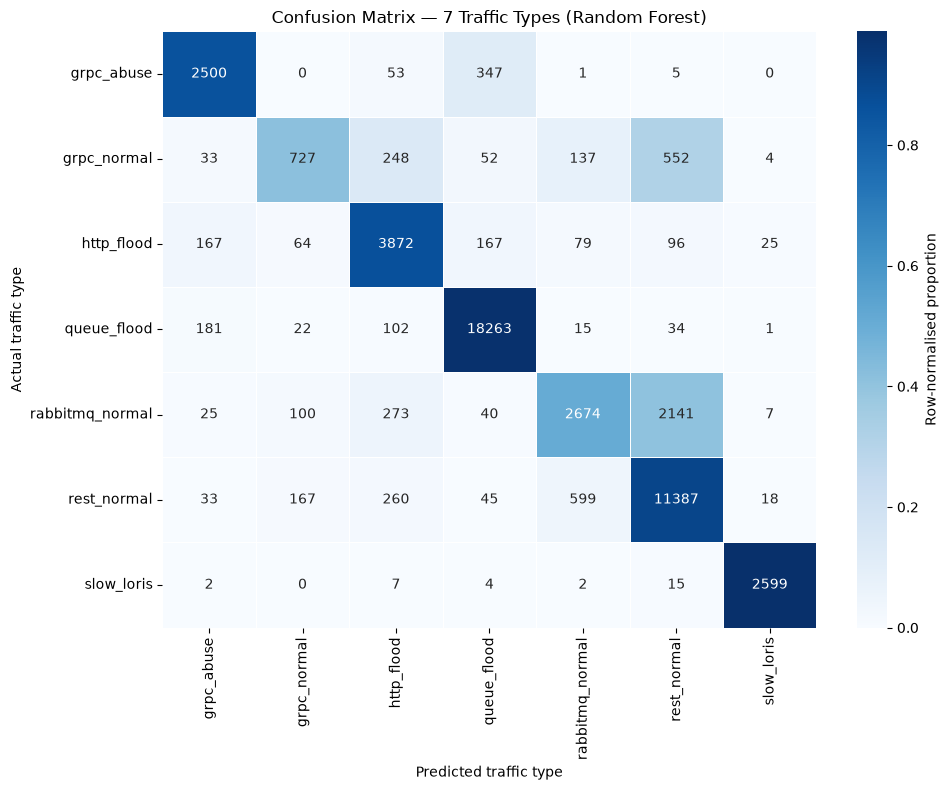

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train model (ONLY if not already trained)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. Predict
y_pred = model.predict(X_test)

# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=cm,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Row-normalised proportion'}
)

ax.set_xlabel('Predicted traffic type')
ax.set_ylabel('Actual traffic type')
ax.set_title('Confusion Matrix — 7 Traffic Types (Random Forest)')

plt.tight_layout()
plt.show()

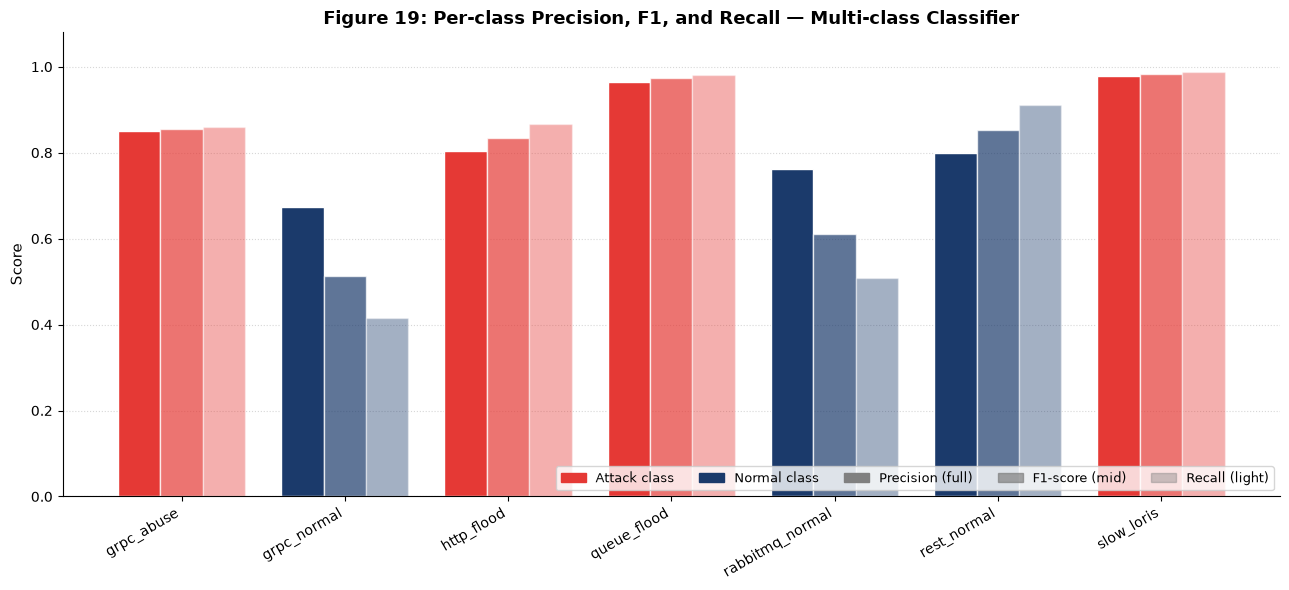

Saved: figure19_multiclass_per_class_f1.png


In [12]:
# ── 6. Figure 19: Per-class F1 bar chart ────────────────
report_dict = classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True
)

f1_scores    = [report_dict[c]['f1-score']  for c in class_names]
precision    = [report_dict[c]['precision'] for c in class_names]
recall_vals  = [report_dict[c]['recall']    for c in class_names]

ATTACK_CLASSES = {
    c for c in class_names
    if df[df['traffic_type']==c]['is_attack'].iloc[0] == 1
}

colors = ['#E53935' if c in ATTACK_CLASSES else '#1B3A6B' for c in class_names]

x = np.arange(len(class_names))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 6))

b1 = ax.bar(x - width, precision,   width, label='Precision',
            color=colors, alpha=1.0,  edgecolor='white')
b2 = ax.bar(x,          f1_scores,  width, label='F1-score',
            color=colors, alpha=0.70, edgecolor='white')
b3 = ax.bar(x + width,  recall_vals, width, label='Recall',
            color=colors, alpha=0.40, edgecolor='white')

ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Figure 19: Per-class Precision, F1, and Recall — Multi-class Classifier',
             fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

attack_patch = mpatches.Patch(color='#E53935', label='Attack class')
normal_patch = mpatches.Patch(color='#1B3A6B', label='Normal class')
prec_patch   = mpatches.Patch(color='grey', alpha=1.0,  label='Precision (full)')
f1_patch     = mpatches.Patch(color='grey', alpha=0.70, label='F1-score (mid)')
rec_patch    = mpatches.Patch(color='grey', alpha=0.40, label='Recall (light)')
ax.legend(handles=[attack_patch, normal_patch, prec_patch, f1_patch, rec_patch],
          fontsize=9, ncol=5, loc='lower right')

plt.tight_layout()
plt.savefig('figure19_multiclass_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure19_multiclass_per_class_f1.png")

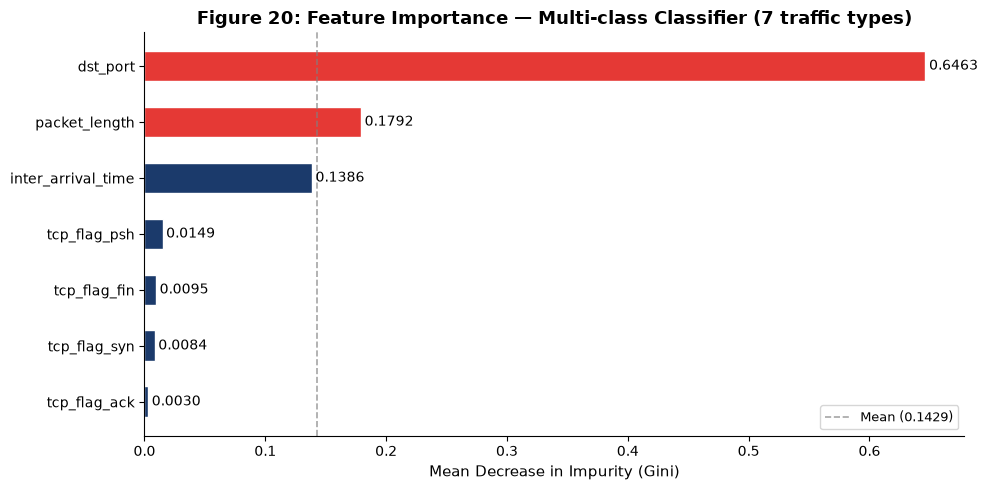

Saved: figure20_multiclass_feature_importance.png


In [13]:
# ── 7. Figure 20: Multi-class feature importance ────────
importances_mc = pd.Series(rf_mc.feature_importances_, index=FEATURE_COLS)

fig, ax = plt.subplots(figsize=(10, 5))
colors_fi = ['#E53935' if v > importances_mc.mean() else '#1B3A6B'
             for v in importances_mc.sort_values().values]
bars = ax.barh(
    importances_mc.sort_values().index,
    importances_mc.sort_values().values,
    color=colors_fi, height=0.55, edgecolor='white'
)
for bar, val in zip(bars, importances_mc.sort_values().values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.axvline(importances_mc.mean(), color='grey', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Mean ({importances_mc.mean():.4f})')
ax.set_xlabel('Mean Decrease in Impurity (Gini)', fontsize=11)
ax.set_title('Figure 20: Feature Importance — Multi-class Classifier (7 traffic types)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figure20_multiclass_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure20_multiclass_feature_importance.png")


In [14]:
# ── 8. Summary ───────────────────────────────────────────
print()
print("="*55)
print("MULTI-CLASS RESULTS SUMMARY")
print("="*55)
print(f"{'Class':<22} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-"*55)
for c in class_names:
    p  = report_dict[c]['precision']
    r  = report_dict[c]['recall']
    f1 = report_dict[c]['f1-score']
    tag = " [ATTACK]" if c in ATTACK_CLASSES else " [NORMAL]"
    print(f"{c:<22} {p:>10.4f} {r:>8.4f} {f1:>8.4f}{tag}")
print("-"*55)
print(f"{'Macro avg':<22} {report_dict['macro avg']['precision']:>10.4f} "
      f"{report_dict['macro avg']['recall']:>8.4f} "
      f"{report_dict['macro avg']['f1-score']:>8.4f}")
print(f"{'Weighted avg':<22} {report_dict['weighted avg']['precision']:>10.4f} "
      f"{report_dict['weighted avg']['recall']:>8.4f} "
      f"{report_dict['weighted avg']['f1-score']:>8.4f}")
print()
print("Figures saved:")
for f in ['figure18_multiclass_confusion.png',
          'figure19_multiclass_per_class_f1.png',
          'figure20_multiclass_feature_importance.png']:
    import os
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    print(f"  {status}  {f}")


MULTI-CLASS RESULTS SUMMARY
Class                   Precision   Recall       F1
-------------------------------------------------------
grpc_abuse                 0.8501   0.8603   0.8551 [ATTACK]
grpc_normal                0.6731   0.4147   0.5132 [NORMAL]
http_flood                 0.8042   0.8662   0.8340 [ATTACK]
queue_flood                0.9654   0.9809   0.9731 [ATTACK]
rabbitmq_normal            0.7625   0.5084   0.6100 [NORMAL]
rest_normal                0.8002   0.9103   0.8517 [NORMAL]
slow_loris                 0.9793   0.9886   0.9839 [ATTACK]
-------------------------------------------------------
Macro avg                  0.8335   0.7899   0.8030
Weighted avg               0.8685   0.8728   0.8657

Figures saved:
  ✗ MISSING  figure18_multiclass_confusion.png
  ✓  figure19_multiclass_per_class_f1.png
  ✓  figure20_multiclass_feature_importance.png
